/tmp/ipykernel_36701/2777322829.py:14: RuntimeWarning: invalid value encountered in sqrt
  dist = np.sqrt(np.sum(diff**2, axis=2))  # shape (h, w)


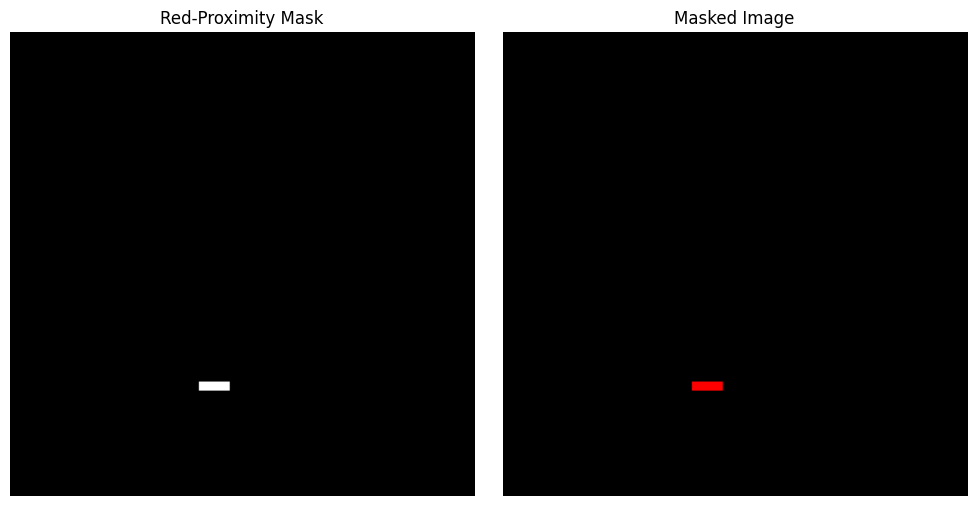

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# (after you’ve computed `mask` and `masked` as above)
# Load your image
img = cv2.imread('40031.png')  # BGR format

# Define the target red color in BGR
target = np.array([0, 0, 255], dtype=np.int16)

# Compute per-pixel Euclidean distance from the target color
diff = img.astype(np.int16) - target  # shape (h, w, 3)
dist = np.sqrt(np.sum(diff**2, axis=2))  # shape (h, w)

# Threshold: keep pixels within this distance of pure red
max_dist = 0  # adjust: lower = more strict, higher = more lenient
mask = (dist <= max_dist).astype(np.uint8) * 255  # binary mask

# Apply mask
masked = cv2.bitwise_and(img, img, mask=mask)

# Convert BGR→RGB for correct color display
masked_rgb = cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Show the binary mask
axes[0].imshow(mask, cmap='gray')
axes[0].set_title('Red-Proximity Mask')
axes[0].axis('off')

# Show the masked image
axes[1].imshow(masked_rgb)
axes[1].set_title('Masked Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [1]:
from FloorplanCategorizer import FloorplanCategorizer

In [2]:
import pandas as pd

In [3]:
categorizer = FloorplanCategorizer()
# df = categorizer.process_directory_to_csv('../data/Tell2Design Data/General Data/floorplan_reoriented', 'floorplan_features.csv')

In [19]:
nnary_df = pd.read_csv("./nnary_features.csv")[:40000]
nnary_df.to_csv("./nnary_features_40000.csv", index=False)

In [15]:
shape_df = pd.read_csv("./shape_features_40000.csv")


In [20]:
shape_df.merge(nnary_df['filename'], on="filename", how="inner").to_csv("./shape_features_40000.csv", index=False)

In [21]:
results = categorizer.categorize_from_csv(
    csv_path='shape_features_40000.csv',
    n_clusters=20
)

Loading features from: shape_features_40000.csv
Loaded 40000 feature vectors with 28 features each
Reduced features from 28 to 14 dimensions


Loading features and preparing data for clustering evaluation...
Loading features from: shape_features_40000.csv
Loaded 40000 feature vectors with 28 features each
Using 14 PCA components for evaluation
Testing k values: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Evaluating k=4...
Evaluating k=5...
Evaluating k=6...
Evaluating k=7...
Evaluating k=8...
Evaluating k=9...
Evaluating k=10...
Evaluating k=11...
Evaluating k=12...
Evaluating k=13...
Evaluating k=14...
Evaluating k=15...
Evaluating k=16...
Evaluating k=17...
Evaluating k=18...
Evaluating k=19...
Evaluating k=20...
Evaluating k=21...
Evaluating k=22...
Evaluating k=23...
Evaluating k=24...
Evaluating k=25...
Evaluating k=26...
Evaluating k=27...
Evaluating k=28...
Evaluating k=29...
Evaluating k=30...
Plots saved to: clustering_evaluation.png


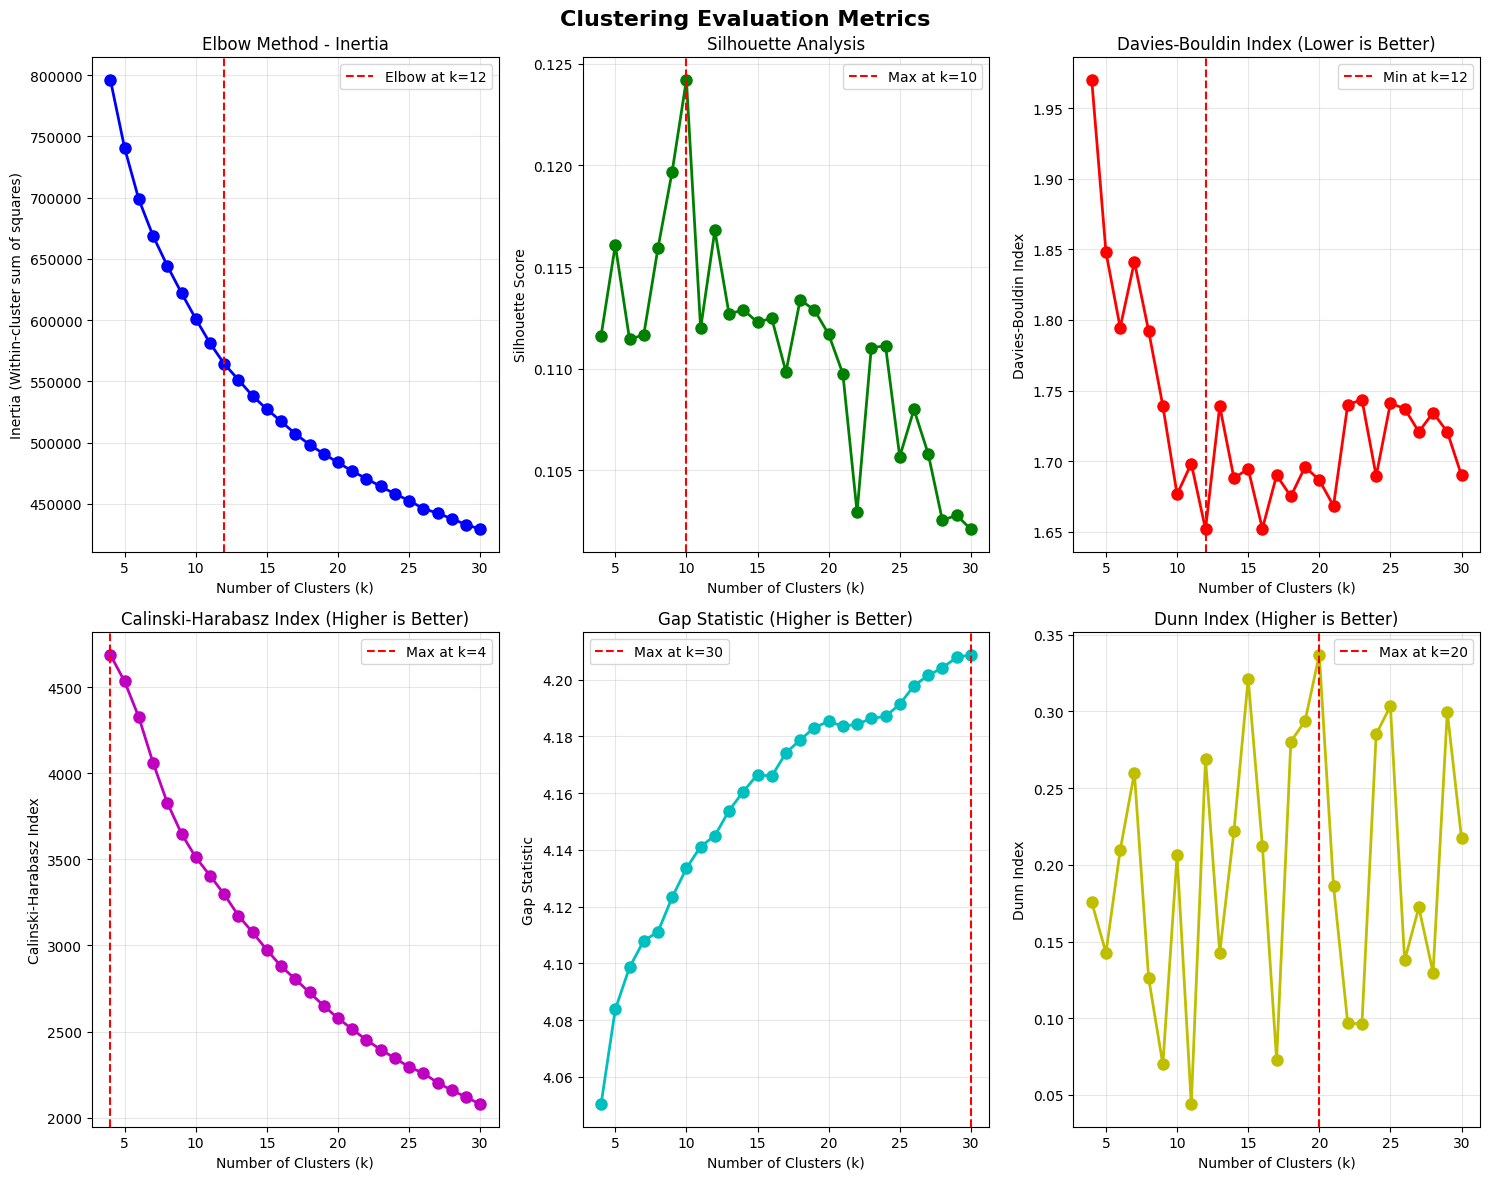


CLUSTERING EVALUATION SUMMARY
Dataset: 40000 samples, 28 original features
PCA reduced to: 14 components

OPTIMAL K RECOMMENDATIONS:
------------------------------
Elbow Inertia            : k = 12
Max Silhouette           : k = 10
Min Davies Bouldin       : k = 12
Max Calinski Harabasz    : k = 4
Max Gap Statistic        : k = 30
Max Dunn Index           : k = 20
Consensus                : k = 12

🎯 CONSENSUS RECOMMENDATION: k = 12



In [4]:
eval_results = categorizer.evaluate_clustering_metrics(
    csv_path='shape_features_40000.csv',
    k_range=range(4, 31),  # Test k from 2 to 30
    plot_results=True,
    save_plots='clustering_evaluation.png'
)

In [18]:
results = categorizer.categorize_from_csv(
    csv_path='shape_features_40000.csv',
    n_clusters=10
)

Loading features from: shape_features_40000.csv
Loaded 40000 feature vectors with 28 features each
Reduced features from 28 to 14 dimensions


In [19]:
analysis_results = categorizer.analyze_clusters(results)

In [20]:
shape_df['cluster_id'] = results['cluster_labels']

In [22]:
shape_df[:1000].to_csv("k10.csv", index=False)